# Notebook 02 — Structure Learning & Parameter Estimation

We compare two Bayesian-network structures on the Cleveland Heart Disease dataset:

1. **Expert DAG** — hand-crafted edges based on clinical knowledge.
2. **Learned DAG** — edges found by greedy hill-climbing with the BIC score.

Both structures are fitted with a Bayesian (BDeu) estimator to produce stable CPTs on the small (n = 242) training set.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pickle

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, ExpertKnowledge
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.structure_score import BIC

plt.rcParams['figure.dpi'] = 110
print('All imports OK')

All imports OK


## 2. Load training data

In [2]:
train = pd.read_csv('heart_train.csv')
test  = pd.read_csv('heart_test.csv')

# pgmpy requires all columns to be string/object dtype
train = train.astype(str)
test  = test.astype(str)

FEATURES = [c for c in train.columns if c != 'target']
print(f'Train: {len(train)} rows  |  Test: {len(test)} rows')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Train: 242 rows  |  Test: 61 rows
Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 3. Expert DAG

Edges are motivated by established cardiology / physiology:

| Direction | Rationale |
|---|---|
| age → trestbps, chol, thalach | Age is a root cause of BP, cholesterol, and reduced max HR |
| sex → chol, thalach | Sex affects lipid metabolism and exercise capacity |
| fbs → chol | Hyperglycaemia raises serum cholesterol |
| trestbps → restecg | Hypertension causes LV hypertrophy / ST-T changes |
| thalach → exang | Lower peak HR is associated with exercise angina |
| slope → oldpeak | ST slope characterises the magnitude of ST depression |
| {cp, chol, trestbps, restecg, exang, oldpeak, ca, thal} → target | Direct clinical predictors |

Every variable appears at least once.

In [3]:
EXPERT_EDGES = [
    # demographic roots
    ('age',  'trestbps'), ('age',  'chol'),  ('age',  'thalach'),
    ('sex',  'chol'),     ('sex',  'thalach'),
    # metabolic chain
    ('fbs',  'chol'),
    # ECG driven by BP
    ('trestbps', 'restecg'),
    # exercise pathway
    ('thalach', 'exang'),
    # ST segment chain
    ('slope', 'oldpeak'),
    # direct predictors of diagnosis
    ('cp',       'target'),
    ('chol',     'target'),
    ('trestbps', 'target'),
    ('restecg',  'target'),
    ('exang',    'target'),
    ('oldpeak',  'target'),
    ('ca',       'target'),
    ('thal',     'target'),
]

expert_model = DiscreteBayesianNetwork(EXPERT_EDGES)
print('Expert DAG created.')
print(f'Nodes: {len(expert_model.nodes())}  |  Edges: {len(expert_model.edges())}')

Expert DAG created.
Nodes: 14  |  Edges: 17


## 4. Structure learning — greedy hill-climbing with BIC

In [4]:
print('Running Hill-Climb search (BIC score) ...')

forbidden = [(n, 'age') for n in train.columns if n != 'age'] + \
            [(n, 'sex') for n in train.columns if n != 'sex']

expert = ExpertKnowledge(forbidden_edges=forbidden)

hc = HillClimbSearch(train)
best_dag = hc.estimate(
    scoring_method='bic-d',
    max_indegree=3,   # keeps CPTs tractable
    max_iter=int(1e4),
    expert_knowledge=expert,
    show_progress=False,
)
learned_model = DiscreteBayesianNetwork(best_dag.edges())
print(f'Learned DAG  — edges: {len(learned_model.edges())}')
print('Edges found:')
for e in sorted(learned_model.edges()):
    print(f'  {e[0]:12s} → {e[1]}')

Running Hill-Climb search (BIC score) ...
Learned DAG  — edges: 8
Edges found:
  cp           → target
  oldpeak      → slope
  oldpeak      → thalach
  target       → ca
  target       → exang
  target       → oldpeak
  target       → thal
  thalach      → exang


## 5. Visualize both DAGs

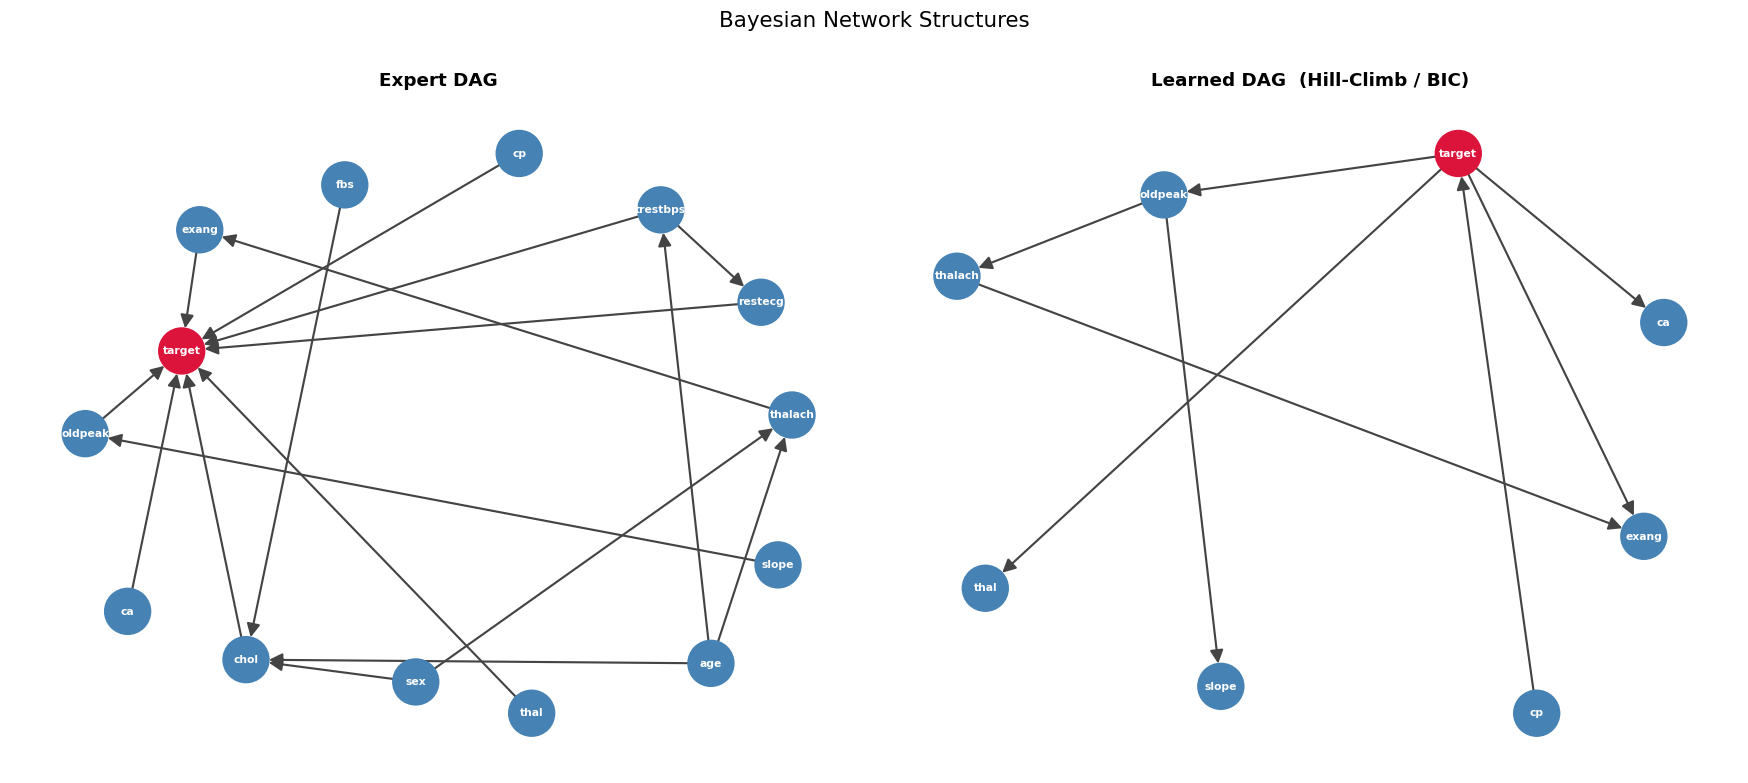

Saved dag_comparison.png


In [5]:
def draw_dag(model, ax, title, highlight='target'):
    G = nx.DiGraph(model.edges())
    # add isolated nodes (if any)
    for n in model.nodes():
        if n not in G:
            G.add_node(n)
    pos = nx.spring_layout(G, seed=179, k=2.5)
    colors = ['crimson' if n == highlight else 'steelblue' for n in G.nodes()]
    nx.draw_networkx(G, pos, ax=ax, node_color=colors, node_size=900,
                     font_size=7, font_color='white', font_weight='bold',
                     arrows=True, arrowsize=18,
                     edge_color='#444444', width=1.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
draw_dag(expert_model,  ax1, 'Expert DAG')
draw_dag(learned_model, ax2, 'Learned DAG  (Hill-Climb / BIC)')
plt.suptitle('Bayesian Network Structures', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('dag_comparison.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved dag_comparison.png')

## 6. Compute BIC scores for both structures

In [6]:
scorer = BIC(train)
expert_bic  = sum(scorer.local_score(node, tuple(expert_model.get_parents(node)))
                  for node in expert_model.nodes())
learned_bic = sum(scorer.local_score(node, tuple(learned_model.get_parents(node)))
                  for node in learned_model.nodes())

print(f'BIC score  Expert : {expert_bic:,.1f}')
print(f'BIC score  Learned: {learned_bic:,.1f}')
print(f'\nHigher (less negative) BIC is better.')
winner = 'Learned' if learned_bic > expert_bic else 'Expert'
print(f'→ {winner} structure has higher BIC on training data.')

BIC score  Expert : -38,570.4
BIC score  Learned: -1,676.6

Higher (less negative) BIC is better.
→ Learned structure has higher BIC on training data.


## 7. Parameter learning — Bayesian estimator (BDeu prior)

With only 242 training samples and CPTs that can have many cells, pure MLE would produce zero-probability entries. BDeu smoothing with `equivalent_sample_size=5` avoids this while staying close to the data.

In [7]:
BDEU_ESS = 5  # equivalent sample size for BDeu prior
bdeu_estimator = DiscreteBayesianEstimator(prior_type='BDeu', equivalent_sample_size=BDEU_ESS)

expert_model = expert_model.fit(train, estimator=bdeu_estimator)
learned_model = learned_model.fit(train, estimator=bdeu_estimator)

print('Parameter learning complete.')
print(f'Expert model: {len(expert_model.get_cpds())} CPDs fitted.')
print(f'Learned model: {len(learned_model.get_cpds())} CPDs fitted.')

Parameter learning complete.
Expert model: 14 CPDs fitted.
Learned model: 8 CPDs fitted.


## 8. Inspect the target CPT (expert model)

In [8]:
target_cpd = expert_model.get_cpds('target')
print(target_cpd)

+-----------+--------------------+-----+------------------+
| ca        | ca(0)              | ... | ca(4)            |
+-----------+--------------------+-----+------------------+
| chol      | chol(borderline)   | ... | chol(high)       |
+-----------+--------------------+-----+------------------+
| cp        | cp(0)              | ... | cp(3)            |
+-----------+--------------------+-----+------------------+
| exang     | exang(0)           | ... | exang(1)         |
+-----------+--------------------+-----+------------------+
| oldpeak   | oldpeak(marked)    | ... | oldpeak(none)    |
+-----------+--------------------+-----+------------------+
| restecg   | restecg(0)         | ... | restecg(2)       |
+-----------+--------------------+-----+------------------+
| thal      | thal(0)            | ... | thal(3)          |
+-----------+--------------------+-----+------------------+
| trestbps  | trestbps(elevated) | ... | trestbps(normal) |
+-----------+--------------------+-----+

## 9. Markov blanket of `target`

The Markov blanket is the minimal set of variables that shields `target` from all other nodes — the ones whose observed values are sufficient to predict diagnosis.

In [9]:
def markov_blanket(model, node):
    parents   = set(model.get_parents(node))
    children  = set(model.get_children(node))
    coparents = set()
    for child in children:
        coparents.update(model.get_parents(child))
    coparents.discard(node)
    return sorted(parents | children | coparents)

mb_expert  = markov_blanket(expert_model,  'target')
mb_learned = markov_blanket(learned_model, 'target')

print(f'Expert  Markov blanket of target ({len(mb_expert)}  vars): {mb_expert}')
print(f'Learned Markov blanket of target ({len(mb_learned)} vars): {mb_learned}')

Expert  Markov blanket of target (8  vars): ['ca', 'chol', 'cp', 'exang', 'oldpeak', 'restecg', 'thal', 'trestbps']
Learned Markov blanket of target (6 vars): ['ca', 'cp', 'exang', 'oldpeak', 'thal', 'thalach']


## 10. Save models

In [10]:
with open('expert_model.pkl', 'wb') as f:
    pickle.dump(expert_model, f)
with open('learned_model.pkl', 'wb') as f:
    pickle.dump(learned_model, f)
print('Models saved to expert_model.pkl and learned_model.pkl')

Models saved to expert_model.pkl and learned_model.pkl
